# Pipeline Demo

This notebook demonstrates the `PhysComp.pipeline` module, which decomposes, fits, assesses and visualises a dataset. This acts as the master function which can perform the majority of functions of this package. This demo is donw on real azimuthal data in order to demonstrate the conclusions and potential application of this project and package.

### Functions covered:
- `pipeline.decomp_fit_pipeline` — Decomposes and fits periodic function to a dataset (optionally assesses or visualises)

#### Needed Imports

In [7]:
### Needed imports for functions
import numpy as np
import matplotlib.pyplot as plt

### Importing the package
import PhysComp as pc

# Using the function

Docstring

    """
    Master function which decomposes dataset and fits periodic function to each pixel. Various other features including visualastion and assessment.
    Works as orchestrator function calling upon all other functions within project.
    
    Required Parameters:
    ----------
    path: str
        path to the data file
    algo: str
        name of algorithm for decomposition e.g. "SVD", "NMF", "sklearn"

    Optional Params:
    ----------
    components: int
        Number of components for reconstruction, if left as None number of components decided via scree plot
    inital: list
        initial guess for parameters, default set if left blank
    scree_plot: bool
        Whether to visualise scree plot
    param_visual: bool
        Whether to visualise fitting parameter map
    error_visual: bool
        Whether to visualise error map
    residual: bool
        Whether to visualise residual map
    r2: bool
        Whether to calculate adjusted r2 value
    signalleak: bool
        Whether to calculate signal leakage
    angle_map, amp_map: str
        Fed into visualise functions
    amp_map: list
        Fed into visualise functions
    verbose: bool
        Wheter each step is logged and signaled for debugging
    
    Returns
    -------
    dict with keys:
    "decomped_data":    arrray : decomposed data set
    "raw_data":         array : raw data set
    "decomped_params":  array : decomposed paramater map,
    "raw_params":       array : raw paramater map,
    "raw_errors":       array : raw errors of paramater map,
    "decomped_errors":  array : decomposed errors of paramater map,
    "raw_r2s":          array : raw adjusted r2 valiues map,
    "decomped_r2s":     array : decomposed adjusted r2 valiues map,
    "signal_leak":      float: signal leakage value
        
    """

The pipeline function calls upon most of the other functions to decompose, fit, visualise and assess. In this notebook we will do all the calculations with pipe.decomp_fit_pipeline but visualise seperately to allow for easier discussion.

The visualisation options can be seen in the doc string of the function but are represented by simple bool variables

The function only requires a file path and a chosen algorithm. Component number is determined by Scree Plot if there is not one given.

NOTE: The warnings are harmless and 

In [2]:
demonstration = pc.decomp_fit_pipeline("LSAT_cropped_demo.npy","SVD",r2=True,signalleak=True,iterative_fitting=True)

WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)


2026-03-18 23:27:02,196 - WARNING - Numba is not installed, falling back to non-accelerated implementation.


WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)


2026-03-18 23:27:02,199 - WARNING - Numba is not installed, falling back to non-accelerated implementation.


WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)


...

2026-03-18 23:27:02,208 - WARNING - Numba is not installed, falling back to non-accelerated implementation.


WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)


2026-03-18 23:27:03,857 - WARNING - Numba is not installed, falling back to non-accelerated implementation.


Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None
Scree Plot: calculated 2 relevant components


Processing slices: 100%|██████████| 9100/9100 [00:45<00:00, 198.51it/s]


#### The demonstration variable now contains a dict with the following keys:

    "decomped_data":    arrray : decomposed data set
    "raw_data":         array : raw data set
    "decomped_params":  array : decomposed paramater map,
    "raw_params":       array : raw paramater map,
    "raw_errors":       array : raw errors of paramater map,
    "decomped_errors":  array : decomposed errors of paramater map,
    "raw_r2s":          array : raw adjusted r2 valiues map,
    "decomped_r2s":     array : decomposed adjusted r2 valiues map,
    "signal_leak":      float: signal leakage value

# Comparing raw and decomposed azimuthal scattering data

#### Below is a demonstration of how to extract and visualise the raw and decomposed data from the output of the pipline function, showing the 0th degree

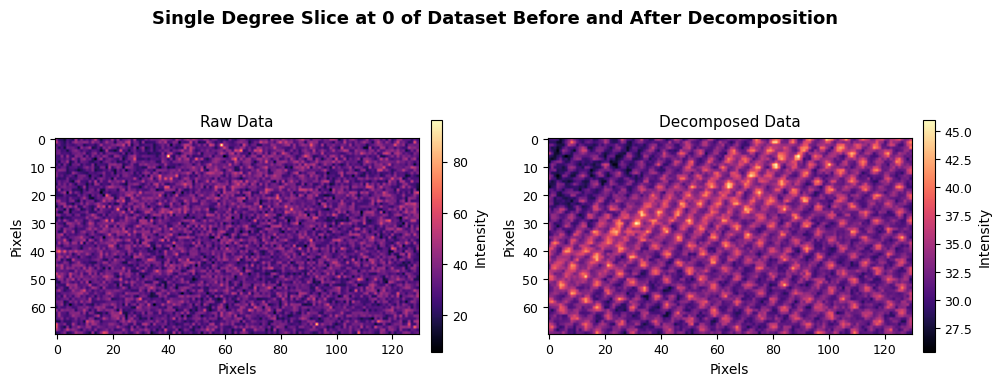

In [3]:
raw_data = demonstration["raw_data"] # unpacking raw data from pipeline output
decomposed_data = demonstration["decomped_data"] # unpacking decomposed data from pipeline output
degree = 0 # Chosen deggree to visualise
pc.visualise_dataset(raw_data,decomposed_data,degree)

#### When comparing the two datasets we see that the decomposition is working, where overall noise is reduced while atomic features are revealed after reconstruction

# Parameter Comparssion

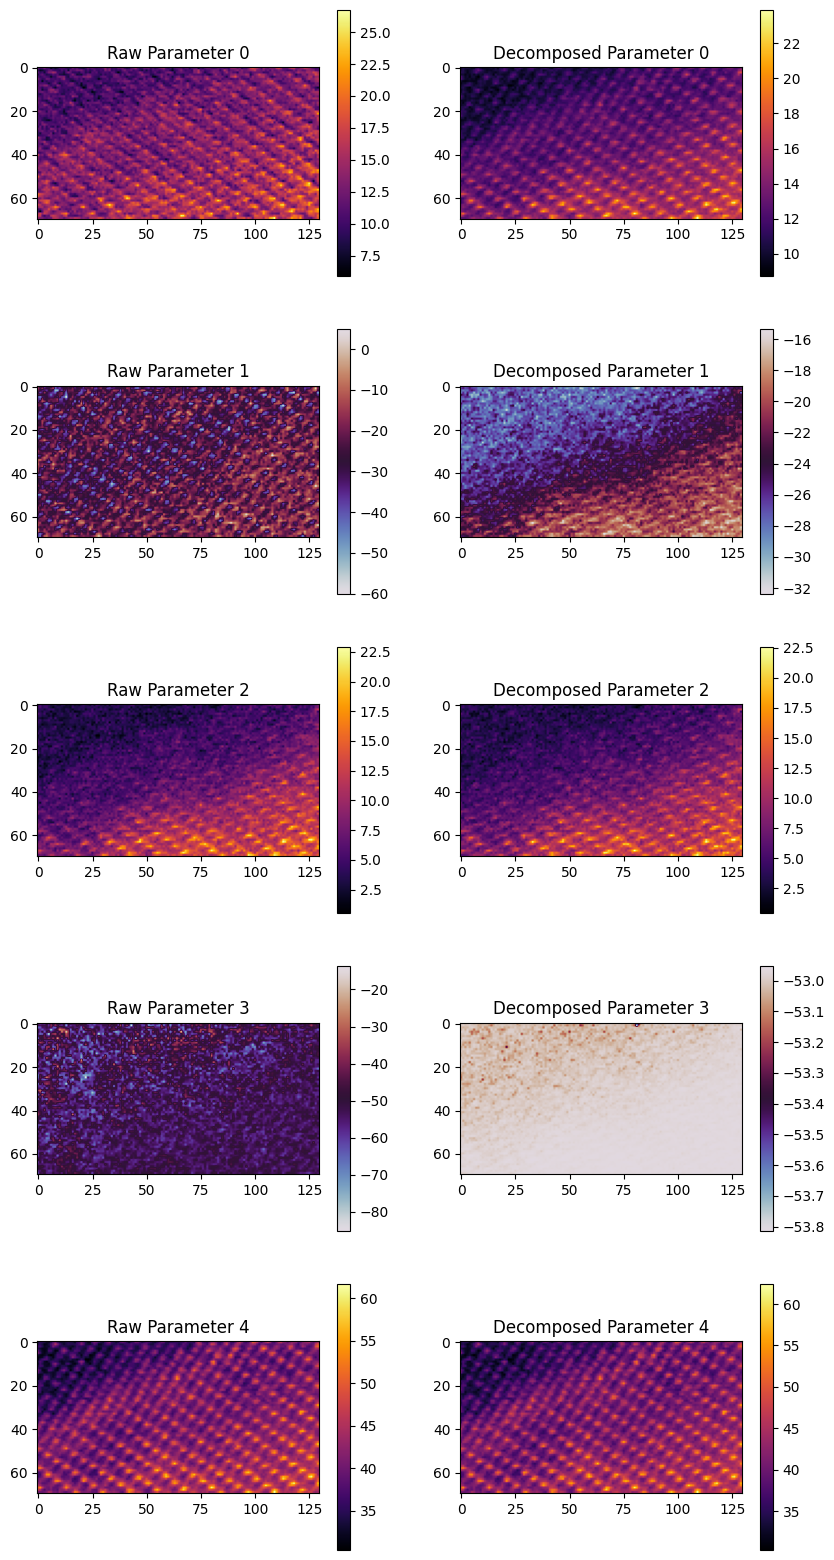

In [4]:
raw_params = demonstration["raw_params"] # unpacking raw parameters from pipeline output
decomposed_params = demonstration["decomped_params"] # unpacking decomposed parameters from pipeline output
params = 5 # Number of parameters

pc.visualise_params(raw_params,decomposed_params,params,"Parameter") #Visualising

#### When comparing the two sets of parameters maps we see that the decomposition is having an effect, revealing features and reducing value ranges after decomposition

# Error Comparssion

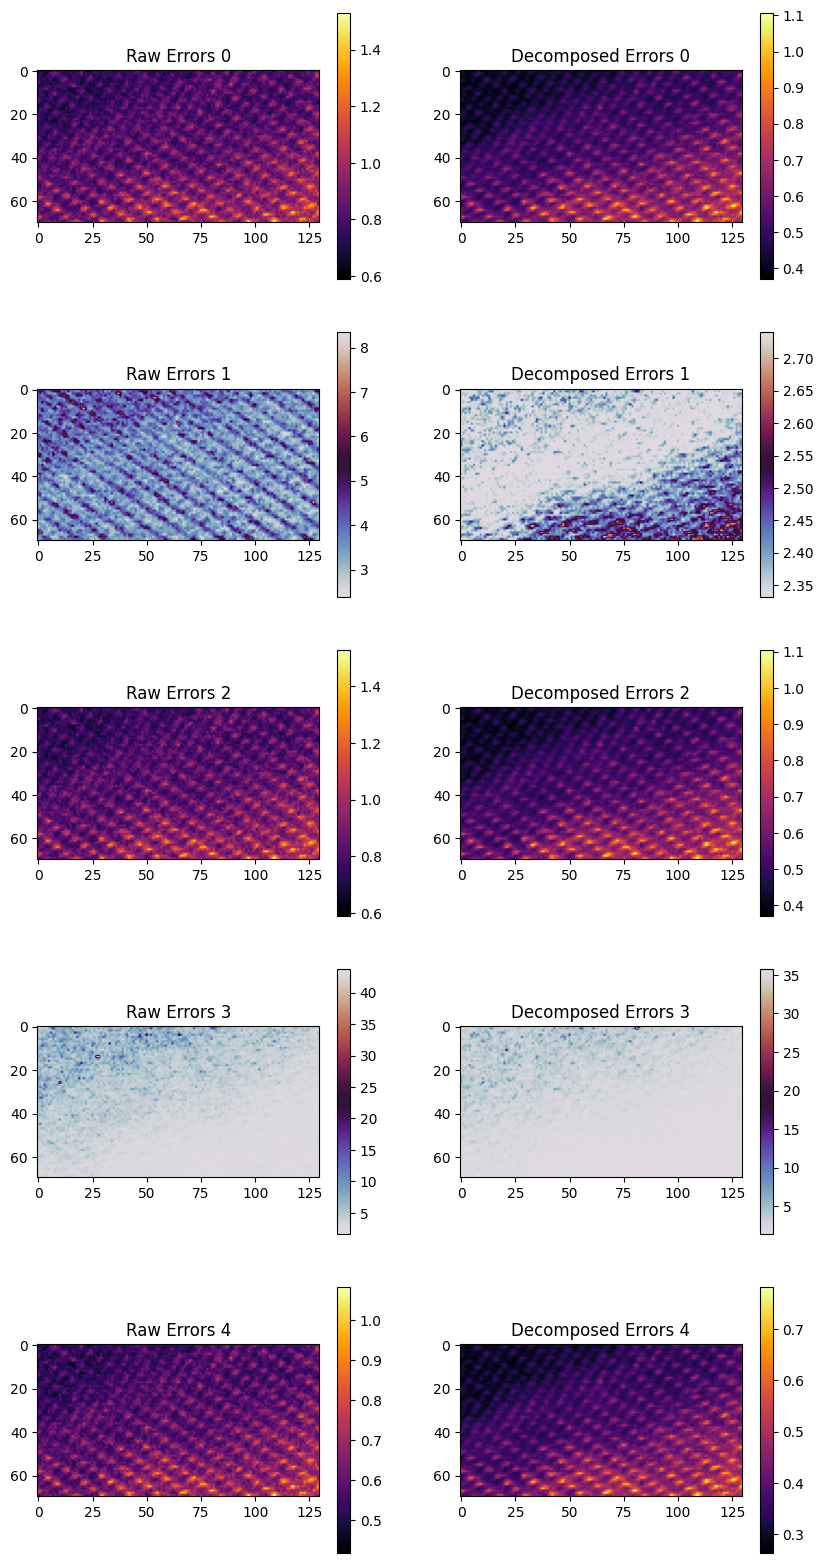

In [5]:
raw_params = demonstration["raw_errors"] # unpacking raw parameters from pipeline output
decomposed_params = demonstration["decomped_errors"] # unpacking decomposed parameters from pipeline output
params = 5 # Number of parameters

pc.visualise_params(raw_params,decomposed_params,params,"Errors") #Visualising

# R2 Values

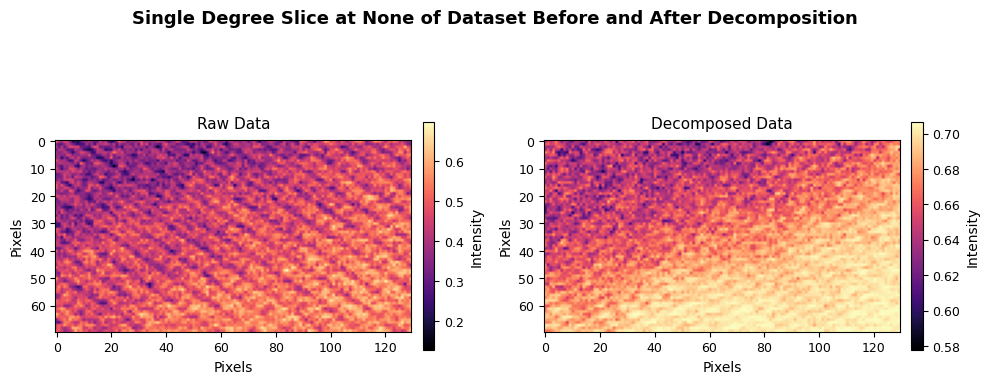

In [6]:
raw_params = np.array(demonstration["raw_r2s"]).reshape(np.shape(demonstration["raw_data"])[0],np.shape(demonstration["raw_data"])[1]) # unpacking raw parameters from pipeline output
decomposed_params = np.array(demonstration["decomped_r2s"]).reshape(np.shape(demonstration["raw_data"])[0],np.shape(demonstration["raw_data"])[1]) # unpacking raw parameters from pipeline output

pc.visualise_dataset(raw_params,decomposed_params,None)

#### $R^2$ values increase across the dataset showing improvement in the fits after decomposition

# Signal Leakage

In [36]:
print(demonstration["signal_leak"])

0.28909387095624106


#### We are losing some signal in the cleanup, could be explored further